In [272]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

In [273]:
stage = "river"

### Reading and compacting dfs

In [274]:
compact = False

In [275]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir('dfs'):
    if file.endswith('.parquet'):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact and len(dfs) > 0:
    print("Compacintg dfs")
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = 'dfs/trash'
    for f in read:
        os.rename(f'dfs/{f}', f'{trash}/{f}')

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f'dfs/compacted_{timestamp}.parquet')

raw_df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage
0,0.000949,0.001175,0.000867,0.001118,0.000547,0.000335,0.000376,0.000019,0.000609,0.000970,...,0,224,65,289,True,False,True,513,1496,river
1,0.000953,0.000382,0.001230,0.000696,0.000345,0.000526,0.000573,0.000548,0.000306,0.001121,...,0,216,47,263,True,False,True,479,1431,river
2,0.000599,0.000679,0.000011,0.001274,0.000049,0.000294,0.001106,0.000297,0.000436,0.000799,...,0,406,151,557,True,False,True,963,1930,river
3,0.000326,0.000179,0.000722,0.000766,0.000419,0.000994,0.000819,0.001090,0.000313,0.000129,...,0,389,77,466,True,False,True,855,2236,river
4,0.000474,0.001348,0.000230,0.000934,0.000944,0.001230,0.000413,0.000513,0.000326,0.000888,...,0,434,63,497,True,False,True,931,2612,river
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,0.001283,0.000388,0.001115,0.000104,0.000934,0.000142,0.001200,0.000053,0.001042,0.000204,...,127,563,133,569,True,True,True,1132,1870,river
84,0.001091,0.000684,0.000999,0.000152,0.000834,0.000940,0.000301,0.000870,0.000676,0.001327,...,27,257,48,278,True,True,True,535,1883,river
85,0.001213,0.001079,0.000178,0.000295,0.001097,0.000687,0.001460,0.000276,0.000758,0.000996,...,64,562,80,578,True,True,True,1140,1960,river
86,0.000948,0.001187,0.001038,0.000264,0.000201,0.000165,0.000110,0.000716,0.000563,0.001327,...,66,123,135,192,True,True,True,315,916,river


In [276]:
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000949,0.001175,0.000867,0.001118,0.000547,0.000335,0.000376,0.000019,0.000609,0.000970,...,0.0,0,224,65,289,True,False,True,513,1496
1,0.000953,0.000382,0.001230,0.000696,0.000345,0.000526,0.000573,0.000548,0.000306,0.001121,...,0.0,0,216,47,263,True,False,True,479,1431
2,0.000599,0.000679,0.000011,0.001274,0.000049,0.000294,0.001106,0.000297,0.000436,0.000799,...,0.0,0,406,151,557,True,False,True,963,1930
3,0.000326,0.000179,0.000722,0.000766,0.000419,0.000994,0.000819,0.001090,0.000313,0.000129,...,0.0,0,389,77,466,True,False,True,855,2236
4,0.000474,0.001348,0.000230,0.000934,0.000944,0.001230,0.000413,0.000513,0.000326,0.000888,...,0.0,0,434,63,497,True,False,True,931,2612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,0.001283,0.000388,0.001115,0.000104,0.000934,0.000142,0.001200,0.000053,0.001042,0.000204,...,1.0,127,563,133,569,True,True,True,1132,1870
84,0.001091,0.000684,0.000999,0.000152,0.000834,0.000940,0.000301,0.000870,0.000676,0.001327,...,0.0,27,257,48,278,True,True,True,535,1883
85,0.001213,0.001079,0.000178,0.000295,0.001097,0.000687,0.001460,0.000276,0.000758,0.000996,...,0.0,64,562,80,578,True,True,True,1140,1960
86,0.000948,0.001187,0.001038,0.000264,0.000201,0.000165,0.000110,0.000716,0.000563,0.001327,...,0.0,66,123,135,192,True,True,True,315,916


In [277]:
# Show all types of columns:
list(sorted(set(["_".join(col.split("_")[0:2]) for col in df.columns])))

['game_size',
 'opponent_bet',
 'opponent_has',
 'player_bet',
 'player_has',
 'player_turn',
 'pot',
 'prob_O',
 'prob_P',
 'public_card',
 'value_of']

### Preprocessing

In [278]:
# Divide all bets by game_size
bet_columns = [
    "player_bet_in_stage",
    "player_bet_in_game",
    "opponent_bet_in_stage",
    "opponent_bet_in_game",
    "pot",
]

def scale_bets(df):
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df[bet_columns]

,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,pot
0,0.000000,0.149733,0.043449,0.193182,0.342914
1,0.000000,0.150943,0.032844,0.183788,0.334731
2,0.000000,0.210363,0.078238,0.288601,0.498964
3,0.000000,0.173971,0.034436,0.208408,0.382379
4,0.000000,0.166156,0.024119,0.190276,0.356432
...,...,...,...,...,...
83,0.067914,0.301070,0.071123,0.304278,0.605348
84,0.014339,0.136484,0.025491,0.147637,0.284121
85,0.032653,0.286735,0.040816,0.294898,0.581633
86,0.072052,0.134279,0.147380,0.209607,0.343886


In [279]:
# Scale range features so that the mean becomes 0 and the standard deviation becomes 1
range_columns = [col for col in df.columns if col.startswith("prob_")]
def scale_ranges(df, training_mean, training_sd):
    df[range_columns] = (df[range_columns] - training_mean) / training_sd
    return df

def get_training_range_mean_and_sd(df):
    return df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std()

def revert_range_scaling(df, training_mean, training_sd):
    df[range_columns] = df[range_columns] * training_sd + training_mean
    return df

mean_training_range_val, sd_training_range_val = get_training_range_mean_and_sd(df)
scale_ranges(df, mean_training_range_val, sd_training_range_val)
print("Original mean and sd of range features:")
print(mean_training_range_val, sd_training_range_val)
print("Mean and sd of range features after scaling:")
print(df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std())
df[range_columns]

Original mean and sd of range features:
0.0007541478129713424 0.00043469654940293584
Mean and sd of range features after scaling:
-6.436340255196986e-17 1.0


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,prob_O_has_hand_1316,prob_O_has_hand_1317,prob_O_has_hand_1318,prob_O_has_hand_1319,prob_O_has_hand_1320,prob_O_has_hand_1321,prob_O_has_hand_1322,prob_O_has_hand_1323,prob_O_has_hand_1324,prob_O_has_hand_1325
0,0.447632,0.968029,0.259871,0.838041,-0.476524,-0.964091,-0.869226,-1.691129,-0.332851,0.496230,...,0.603145,0.587707,0.073587,-1.346630,-1.721447,0.248183,-1.281648,-1.585487,-0.437798,1.293371
1,0.457630,-0.856730,1.094788,-0.134619,-0.940298,-0.524194,-0.416858,-0.473121,-1.030356,0.844700,...,-0.318833,-0.480737,0.572130,1.751121,-0.622678,0.203193,-0.352539,1.507168,-0.924135,-1.302409
2,-0.358019,-0.172618,-1.709064,1.196305,-1.622333,-1.058964,0.810213,-1.051403,-0.731854,0.102937,...,-0.899856,1.105163,1.483577,-0.360452,0.554397,0.343739,0.904175,0.753208,0.110205,-1.639931
3,-0.984905,-1.323854,-0.074692,0.026534,-0.770492,0.552149,0.148203,0.773293,-1.015099,-1.437954,...,0.935295,-1.535123,-0.740256,0.233620,-0.371679,-1.614754,-0.295564,0.021584,1.282811,-0.661264
4,-0.644175,1.365336,-1.206507,0.413123,0.437460,1.094318,-0.784951,-0.555873,-0.984698,0.306775,...,0.470366,-1.388729,-1.643143,1.525464,0.434030,-0.564423,-0.773876,-0.678953,-0.498538,0.080052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,1.216166,-0.842954,0.830597,-1.494658,0.413056,-1.407186,1.025762,-1.612415,0.662424,-1.265991,...,-0.226808,0.017420,1.134020,-0.678850,1.026019,-0.240055,0.161682,1.689526,0.526822,1.220554
84,0.775685,-0.160311,0.562167,-1.384983,0.184724,0.428689,-1.043411,0.266128,-0.178750,1.318597,...,0.998607,1.538985,-1.082504,0.584714,-0.938441,-0.414526,-0.101807,0.233030,-1.428359,1.314624
85,1.055413,0.747100,-1.324579,-1.055119,0.788140,-0.153848,1.622777,-1.099165,0.008628,0.555734,...,-0.843147,-0.993914,1.378729,0.440845,-1.201684,0.684192,0.555158,1.241044,-0.970380,-1.448062
86,0.444960,0.996353,0.653396,-1.127317,-1.271394,-1.354433,-1.482240,-0.088537,-0.440719,1.316870,...,-0.123958,-1.242202,-0.498068,-1.641765,1.536033,1.553761,-0.174083,0.509911,-0.382383,1.534539


In [280]:
# Scale node values (target variable) so that the mean becomes 0 and the standard deviation becomes 1
value_columns = [col for col in df.columns if col.startswith("value_")]

"""
# Commented out, because we probably don't need it (target is already at scale [-1, 1])
def scale_values(df, training_mean, training_sd):
    df[value_columns] = (df[value_columns] - training_mean) / training_sd
    return df


def get_training_target_mean_and_sd(df):
    return df[value_columns].to_numpy().mean(), df[value_columns].to_numpy().std()


def revert_value_scaling(arr: np.array, training_mean, training_sd):
    return arr * training_sd + training_mean


mean_training_value_val, sd_training_value_val = get_training_target_mean_and_sd(df)
orig_values = df[value_columns]
scale_values(df, mean_training_value_val, sd_training_value_val)
print("Original mean and sd of values:")
print(orig_values.to_numpy().mean())
print(orig_values.to_numpy().std())
print("New mean and sd of values:")
print(df[value_columns].to_numpy().mean())
print(df[value_columns].to_numpy().std())
# Check revert function
assert np.allclose(
    revert_value_scaling(df, mean_training_value_val, sd_training_value_val)[
        value_columns
    ].to_numpy(),
    orig_values.to_numpy(),
)
df[value_columns] """
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())
df[value_columns]

Mean of target variable: -0.0017981711150189643
SD of target variable: 0.12339705720219184
Min of target variable: -0.3554668813288401
Max of target variable: 0.5294530942395186


,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
0,-0.081638,-0.000498,-0.028550,-0.090864,0.070579,0.067363,0.060463,0.050083,0.000000,0.034855,...,-0.061026,0.024404,0.010037,0.001629,-0.062474,-0.065114,-0.067324,0.008741,0.000099,-0.002278
1,0.241291,-0.000329,0.202978,0.056633,0.032012,0.016464,0.005828,0.000817,-0.052290,-0.020656,...,0.000000,0.000000,-0.041838,-0.064753,0.000000,0.000000,0.000000,0.000000,0.000000,-0.047671
2,0.001929,0.379400,0.334204,-0.000464,-0.000783,-0.097363,-0.000641,0.000000,0.263324,0.077466,...,-0.000957,-0.000996,-0.000999,-0.017562,0.061099,0.032305,0.010830,0.025084,0.005923,0.005152
3,0.072178,0.000316,0.066442,-0.000460,0.059202,-0.010708,0.048682,0.032374,0.018234,0.005971,...,0.010835,0.002015,-0.045242,-0.066926,0.000951,-0.048285,-0.069988,-0.051346,-0.072479,-0.092398
4,0.000000,0.253612,0.221163,0.104365,-0.000647,0.000000,-0.030952,0.076358,0.051061,-0.051772,...,-0.092373,0.000000,0.016166,0.002134,0.000000,0.015301,0.002531,0.000000,0.000000,0.002380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,0.336584,0.000000,0.336863,0.000000,0.305600,-0.124293,0.273157,0.216181,0.155052,0.082811,...,0.117640,0.042126,-0.049881,0.000000,0.028290,-0.062023,0.000000,-0.071863,0.000000,0.000000
84,0.087952,0.087523,0.000000,0.088410,0.087928,0.088180,0.088411,0.088461,0.000000,-0.027202,...,0.000000,-0.025393,-0.041826,-0.100123,0.000000,0.000000,0.000000,-0.041544,-0.099804,-0.100943
85,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.198813,0.134728,0.058466,-0.029758,0.123605,0.048428,-0.038468,0.039798,-0.048644,-0.060324
86,0.232313,0.000000,0.231476,-0.055431,0.207011,0.179098,-0.090490,0.136138,0.091356,0.038634,...,0.071594,0.018116,-0.124782,-0.047651,0.010582,-0.127127,-0.053973,-0.129785,-0.030646,-0.132519


In [281]:
# Make boolean features 0 or 1
def encode_bools(df):
    bool_columns = [
        "player_turn",
        "player_has_bet",
        "opponent_has_bet",
    ]
    df[bool_columns] = df[bool_columns].astype(int)
    return df

df = encode_bools(df)
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.447632,0.968029,0.259871,0.838041,-0.476524,-0.964091,-0.869226,-1.691129,-0.332851,0.496230,...,0.0,0.000000,0.149733,0.043449,0.193182,1,0,1,0.342914,1496
1,0.457630,-0.856730,1.094788,-0.134619,-0.940298,-0.524194,-0.416858,-0.473121,-1.030356,0.844700,...,0.0,0.000000,0.150943,0.032844,0.183788,1,0,1,0.334731,1431
2,-0.358019,-0.172618,-1.709064,1.196305,-1.622333,-1.058964,0.810213,-1.051403,-0.731854,0.102937,...,0.0,0.000000,0.210363,0.078238,0.288601,1,0,1,0.498964,1930
3,-0.984905,-1.323854,-0.074692,0.026534,-0.770492,0.552149,0.148203,0.773293,-1.015099,-1.437954,...,0.0,0.000000,0.173971,0.034436,0.208408,1,0,1,0.382379,2236
4,-0.644175,1.365336,-1.206507,0.413123,0.437460,1.094318,-0.784951,-0.555873,-0.984698,0.306775,...,0.0,0.000000,0.166156,0.024119,0.190276,1,0,1,0.356432,2612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,1.216166,-0.842954,0.830597,-1.494658,0.413056,-1.407186,1.025762,-1.612415,0.662424,-1.265991,...,1.0,0.067914,0.301070,0.071123,0.304278,1,1,1,0.605348,1870
84,0.775685,-0.160311,0.562167,-1.384983,0.184724,0.428689,-1.043411,0.266128,-0.178750,1.318597,...,0.0,0.014339,0.136484,0.025491,0.147637,1,1,1,0.284121,1883
85,1.055413,0.747100,-1.324579,-1.055119,0.788140,-0.153848,1.622777,-1.099165,0.008628,0.555734,...,0.0,0.032653,0.286735,0.040816,0.294898,1,1,1,0.581633,1960
86,0.444960,0.996353,0.653396,-1.127317,-1.271394,-1.354433,-1.482240,-0.088537,-0.440719,1.316870,...,0.0,0.072052,0.134279,0.147380,0.209607,1,1,1,0.343886,916


In [282]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,0.447632,0.968029,0.259871,0.838041,-0.476524,-0.964091,-0.869226,-1.691129,-0.332851,0.496230,...,0.0,0.0,0.000000,0.149733,0.043449,0.193182,1,0,1,0.342914
1,0.457630,-0.856730,1.094788,-0.134619,-0.940298,-0.524194,-0.416858,-0.473121,-1.030356,0.844700,...,0.0,0.0,0.000000,0.150943,0.032844,0.183788,1,0,1,0.334731
2,-0.358019,-0.172618,-1.709064,1.196305,-1.622333,-1.058964,0.810213,-1.051403,-0.731854,0.102937,...,0.0,0.0,0.000000,0.210363,0.078238,0.288601,1,0,1,0.498964
3,-0.984905,-1.323854,-0.074692,0.026534,-0.770492,0.552149,0.148203,0.773293,-1.015099,-1.437954,...,0.0,0.0,0.000000,0.173971,0.034436,0.208408,1,0,1,0.382379
4,-0.644175,1.365336,-1.206507,0.413123,0.437460,1.094318,-0.784951,-0.555873,-0.984698,0.306775,...,0.0,0.0,0.000000,0.166156,0.024119,0.190276,1,0,1,0.356432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,1.216166,-0.842954,0.830597,-1.494658,0.413056,-1.407186,1.025762,-1.612415,0.662424,-1.265991,...,0.0,1.0,0.067914,0.301070,0.071123,0.304278,1,1,1,0.605348
84,0.775685,-0.160311,0.562167,-1.384983,0.184724,0.428689,-1.043411,0.266128,-0.178750,1.318597,...,0.0,0.0,0.014339,0.136484,0.025491,0.147637,1,1,1,0.284121
85,1.055413,0.747100,-1.324579,-1.055119,0.788140,-0.153848,1.622777,-1.099165,0.008628,0.555734,...,0.0,0.0,0.032653,0.286735,0.040816,0.294898,1,1,1,0.581633
86,0.444960,0.996353,0.653396,-1.127317,-1.271394,-1.354433,-1.482240,-0.088537,-0.440719,1.316870,...,0.0,0.0,0.072052,0.134279,0.147380,0.209607,1,1,1,0.343886


### Data validation

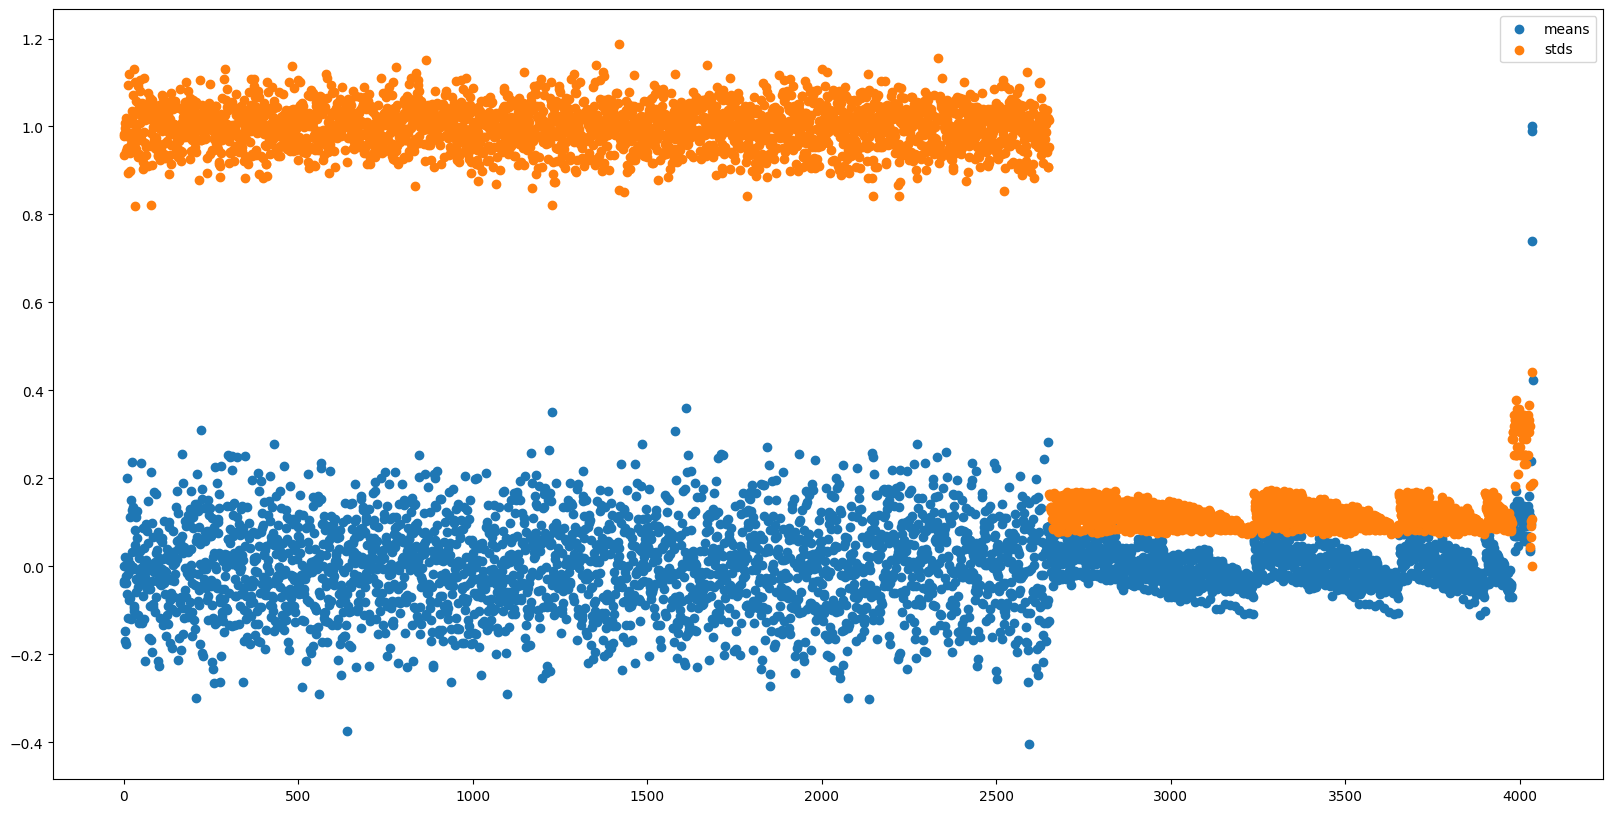

In [283]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means")
plt.scatter(range(df.std().size), df.std(), label="stds")
plt.legend()
plt.show()

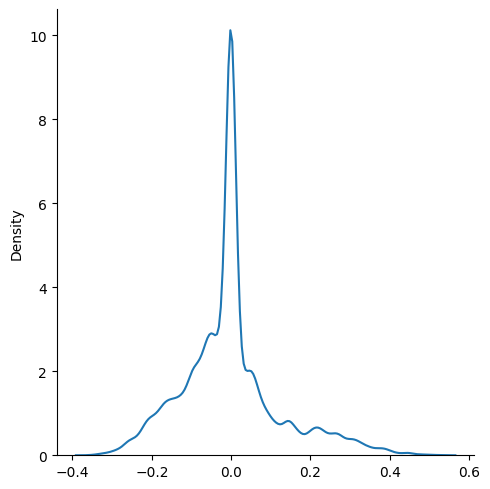

In [284]:
# Plot distribution of output values in a bell curve
from seaborn import displot

displot(raw_df[value_columns].to_numpy().flatten(), kind="kde")
plt.show()


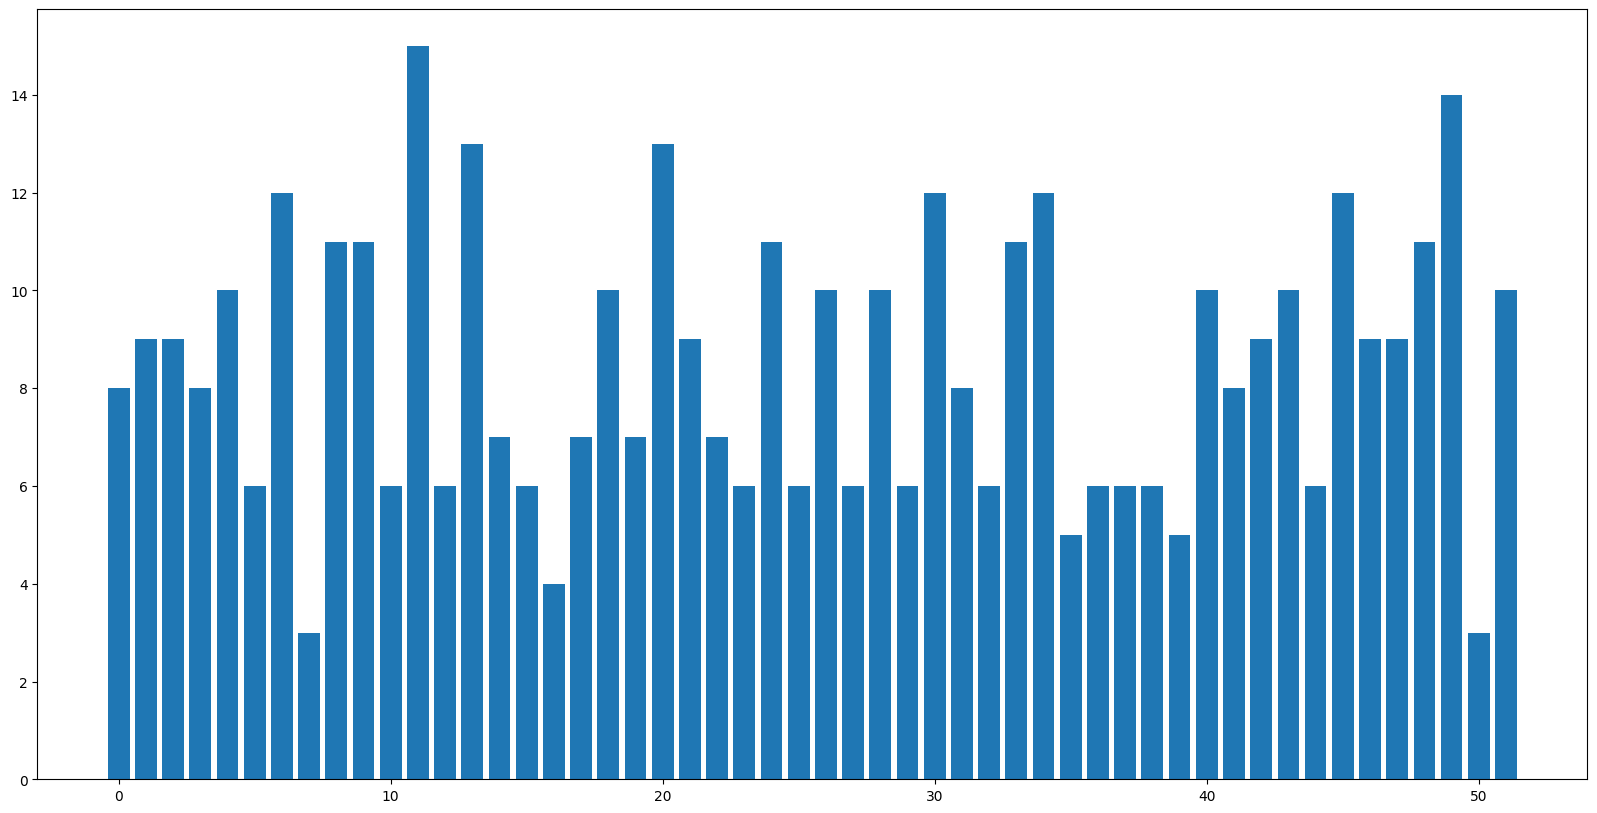

In [285]:
# Check representation of possible public cards
card_cols = [col for col in df.columns if col.startswith("public_card_")]
card_counts = df[card_cols].sum()
fig, ax = plt.subplots(figsize=(20, 10))
plt.bar(range(len(card_counts)), card_counts)
plt.show()

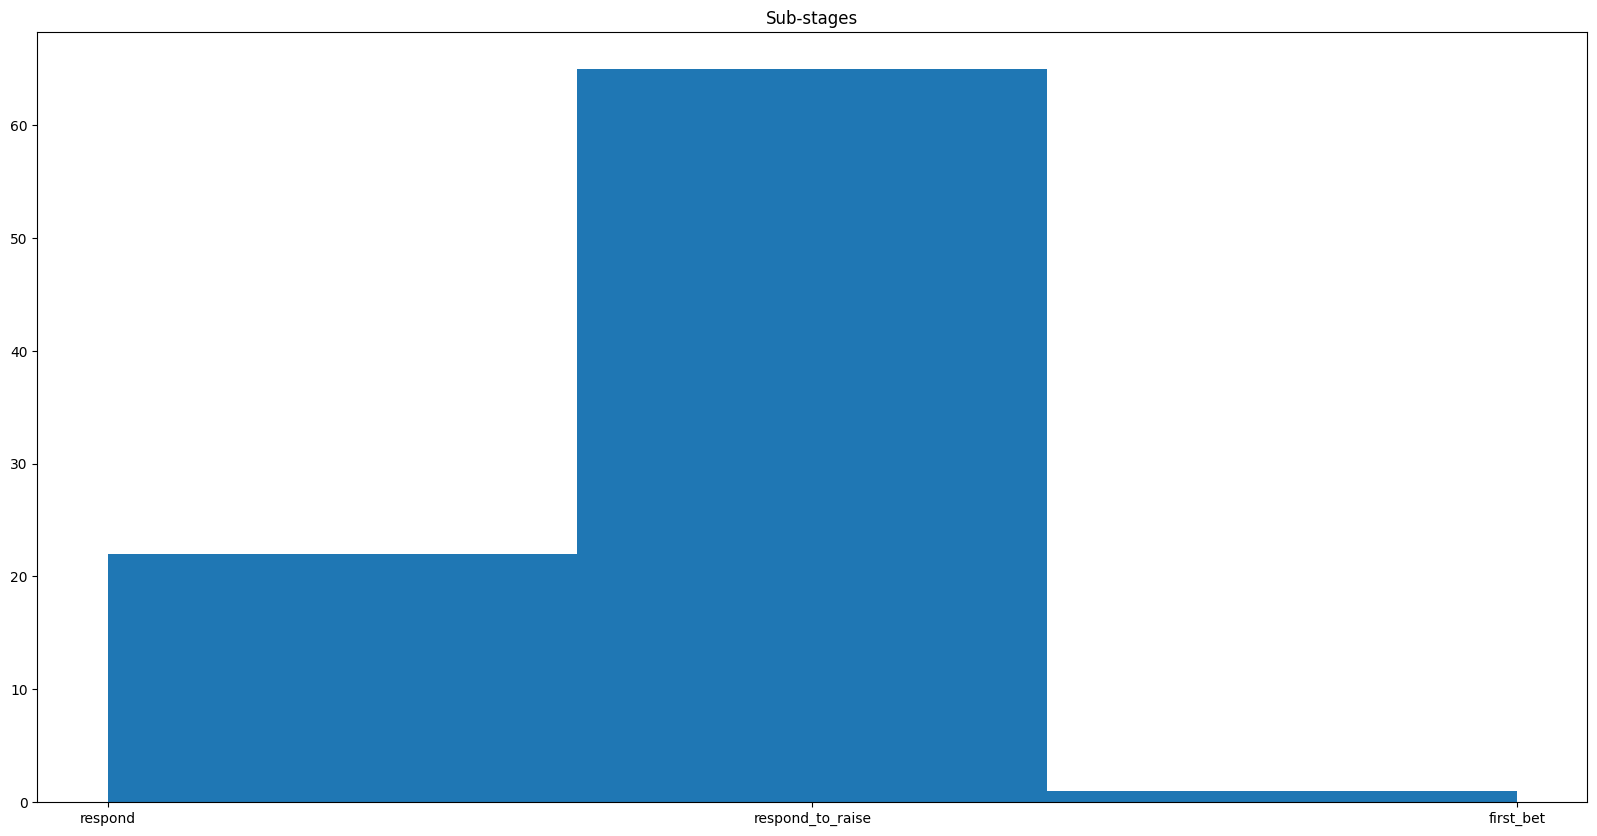

In [286]:
sub_stages = np.where(
    df["player_has_bet"] & df["opponent_has_bet"],
    "respond_to_raise",
    np.where(
        df["opponent_has_bet"],
        "respond",
        "first_bet"
    )
)
fig, ax = plt.subplots(figsize=(20, 10))
plt.hist(sub_stages, bins=3)
plt.title("Sub-stages")
plt.show()

In [287]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(88, 2712) (88, 1326)


### Structure for Neural Network

In [288]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [289]:
def generate_model():
    # Define input layer
    input_layer = Input(shape=(X.shape[1],), name="input_layer")

    # Define hidden layers
    hidden_layer_1 = Dense(128, activation="relu", name="hidden_layer_1")(input_layer)
    hidden_layer_2 = Dense(64, activation="relu", name="hidden_layer_2")(hidden_layer_1)
    hidden_layer_3 = Dense(32, activation="relu", name="hidden_layer_3")(hidden_layer_2)

    # Define value layer for player 1
    value_layer_P1 = Dense(Y.shape[1], activation="linear", name="value_layer_P1")(
        hidden_layer_3
    )

    model = Model(inputs=input_layer, outputs=value_layer_P1)
    model.compile(optimizer='adam', loss='mean_squared_error')

    return model

### Cross validation

In [290]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# This will store the fold results
fold_results = []

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Loop over each fold
for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    # Split the data into k-fold training and validation sets
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    print("@@@ FOLD", i+1, "@@@")
    print("Size of training set:", X_train_fold.shape[0])
    
    # Define and compile the neural network inside the loop to reset weights for each fold
    model = generate_model()
    
    # Train the model
    history = model.fit(
        X_train_fold, Y_train_fold,
        epochs=1000,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=[early_stopping]  # Include the early stopping callback here
    )
    
    # Save the history in fold_results
    fold_results.append(history.history)

@@@ FOLD 0 @@@
Size of training set: 56
Epoch 1/100


2024-04-29 17:14:24.636753: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


2/2 [==============================] - ETA: 0s - loss: 0.1712

2024-04-29 17:14:25.170383: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


2/2 [==============================] - 1s 493ms/step - loss: 0.1712 - val_loss: 0.1483
Epoch 2/100
2/2 [==============================] - 0s 82ms/step - loss: 0.1056 - val_loss: 0.1352
Epoch 3/100
2/2 [==============================] - 0s 84ms/step - loss: 0.1085 - val_loss: 0.1250
Epoch 4/100
2/2 [==============================] - 0s 81ms/step - loss: 0.1183 - val_loss: 0.1161
Epoch 5/100
2/2 [==============================] - 0s 60ms/step - loss: 0.1254 - val_loss: 0.1082
Epoch 6/100
2/2 [==============================] - 0s 70ms/step - loss: 0.1275 - val_loss: 0.1011
Epoch 7/100
2/2 [==============================] - 0s 78ms/step - loss: 0.1234 - val_loss: 0.0950
Epoch 8/100
2/2 [==============================] - 0s 65ms/step - loss: 0.1178 - val_loss: 0.0896
Epoch 9/100
2/2 [==============================] - 0s 67ms/step - loss: 0.1099 - val_loss: 0.0846
Epoch 10/100
2/2 [==============================] - 0s 51ms/step - loss: 0.1043 - val_loss: 0.0801
Epoch 11/100
2/2 [============

...

2/2 [==============================] - 0s 95ms/step - loss: 0.1059 - val_loss: 0.1389
Epoch 3/100
2/2 [==============================] - 0s 99ms/step - loss: 0.1136 - val_loss: 0.1299
Epoch 4/100
2/2 [==============================] - 0s 65ms/step - loss: 0.1252 - val_loss: 0.1220
Epoch 5/100
2/2 [==============================] - 0s 80ms/step - loss: 0.1302 - val_loss: 0.1147
Epoch 6/100
2/2 [==============================] - 0s 64ms/step - loss: 0.1279 - val_loss: 0.1080
Epoch 7/100
2/2 [==============================] - 0s 63ms/step - loss: 0.1222 - val_loss: 0.1018
Epoch 8/100
2/2 [==============================] - 0s 65ms/step - loss: 0.1162 - val_loss: 0.0961
Epoch 9/100
2/2 [==============================] - 0s 76ms/step - loss: 0.1143 - val_loss: 0.0909
Epoch 10/100
2/2 [==============================] - 0s 84ms/step - loss: 0.1131 - val_loss: 0.0860
Epoch 11/100
2/2 [==============================] - 0s 60ms/step - loss: 0.1112 - val_loss: 0.0814
Epoch 12/100
2/2 [============

2024-04-29 17:15:22.412448: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


2/2 [==============================] - 1s 350ms/step - loss: 0.1631 - val_loss: 0.1670
Epoch 2/100
1/2 [==============>...............] - ETA: 0s - loss: 0.1040

2024-04-29 17:15:22.915600: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


2/2 [==============================] - 0s 82ms/step - loss: 0.0976 - val_loss: 0.1552
Epoch 3/100
2/2 [==============================] - 0s 76ms/step - loss: 0.0973 - val_loss: 0.1453
Epoch 4/100
2/2 [==============================] - 0s 62ms/step - loss: 0.1038 - val_loss: 0.1363
Epoch 5/100
2/2 [==============================] - 0s 76ms/step - loss: 0.1074 - val_loss: 0.1281
Epoch 6/100
2/2 [==============================] - 0s 67ms/step - loss: 0.1068 - val_loss: 0.1207
Epoch 7/100
2/2 [==============================] - 0s 56ms/step - loss: 0.1033 - val_loss: 0.1142
Epoch 8/100
2/2 [==============================] - 0s 61ms/step - loss: 0.0977 - val_loss: 0.1081
Epoch 9/100
2/2 [==============================] - 0s 66ms/step - loss: 0.0921 - val_loss: 0.1025
Epoch 10/100
2/2 [==============================] - 0s 67ms/step - loss: 0.0884 - val_loss: 0.0971
Epoch 11/100
2/2 [==============================] - 0s 66ms/step - loss: 0.0862 - val_loss: 0.0920
Epoch 12/100
2/2 [============

In [291]:
mse_scores = []

# Evaluate each fold
for fold_history in fold_results:
    val_mse_per_epoch = fold_history['val_loss']
    mse_scores.append(val_mse_per_epoch[-1])  # Take the last epoch MSE

# Calculate the average and standard deviation of the MSE scores across all folds
average_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Cross-Validation MSE: {average_mse:.4f} (+/- {std_dev_mse:.4f})")
rmse = np.sqrt(average_mse)
rmse_std_dev = np.sqrt(std_dev_mse)
print(f"Cross-Validation RMSE: {rmse:.4f} (+/- {rmse_std_dev:.4f})")

Cross-Validation MSE: 0.0229 (+/- 0.0015)
Cross-Validation RMSE: 0.1512 (+/- 0.0387)


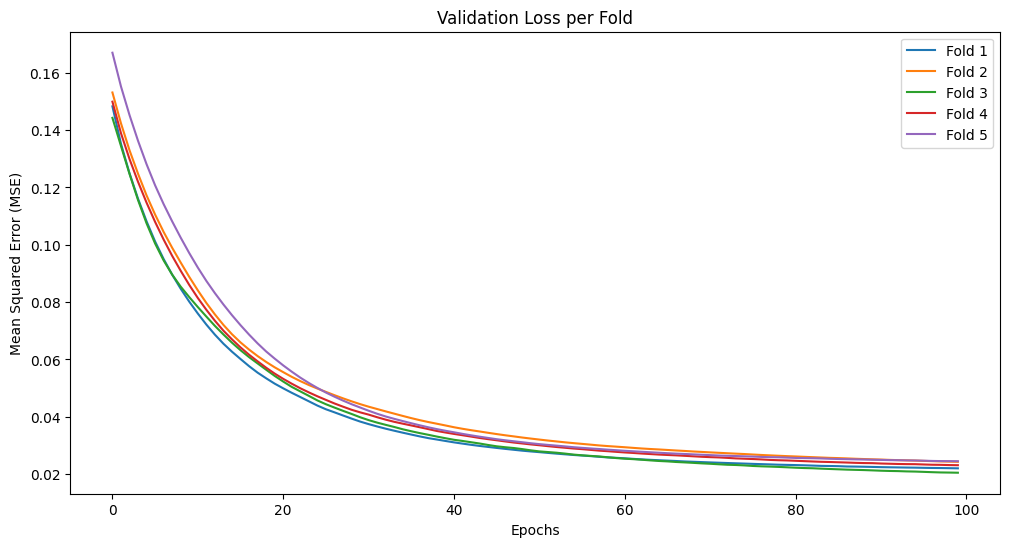

In [292]:
plt.figure(figsize=(12, 6))
for i, fold_history in enumerate(fold_results, 1):
    plt.plot(fold_history['val_loss'], label=f'Fold {i}')

plt.title('Validation Loss per Fold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

In [293]:
# Find optimal number of epochs
optimal_epochs = []

for result in fold_results:
    val_loss_per_epoch = result['val_loss']
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch))
    optimal_epochs.append(best_epoch)

average_optimal_epoch = np.mean(optimal_epochs)
buffer = 5  # Add a small buffer to avoid underfitting
final_epoch_number = int(average_optimal_epoch + buffer)

print(f"Suggested number of epochs for final training: {final_epoch_number}")

Suggested number of epochs for final training: 104
